# Consistency Check #

This notebook performs the consistency check between:\
	•	the numerical background computed in Background.ipynb, and\
	•	the CLASS background extracted in CLASS.ipynb.

Then, using this comparison, we:\
	1.	correct the numerical Hubble function so that it matches *CLASS*,\
	2.	recompute the conformal-time evolution using the corrected Hubble rate,\
	3.	evolve the scalar field $\chi(\tau)$ on this corrected background,\
	4.	compute the equation-of-state parameter $\omega_\chi(z)$.

The goal is to ensure that the scalar-field evolution is conformal to the one of the paper.

In [1]:
import classy as cl
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

Here we load the CLASS background computed earlier:\
	•	scale factor $a = \frac{1}{1+z}$\
	•	Hubble function $H_{\rm CLASS}(a)$\
	•	conformal time $\tau_{\rm CLASS}(a)$

These functions provide the benchmark we want to reproduce with the analytic model.

In [2]:
cosmo=cl.Class()
parameters={'h':0.6736, 'omega_b':0.02237, 'omega_cdm':0.12, 'A_s':2.1e-9, 'n_s':0.965, 'tau_reio':0.054}
cosmo.set(parameters)
cosmo.compute()
bg=cosmo.get_background()

In [3]:
H_class=np.array(bg['H [1/Mpc]'])
a_class=1/(1+np.array(bg['z']))
tau_class=np.array(bg['conf. time [Mpc]'])
H_class_of_a=sp.interpolate.interp1d(a_class, H_class, kind='cubic', fill_value='extrapolate')

In [4]:
Omegam=0.3153
Omegar=9.04e-5
OmegaL=0.6847
Omegak=0.0
H0=2.192e-4 # in 1/Mpc
Mpl=1.22e28*1.5637e29 # in 1/Mpc
mpl=Mpl/np.sqrt(8*np.pi)

def H(a):
    return H0*np.sqrt(Omegar*a**(-4)+Omegam*a**(-3)+Omegak*a**(-2)+OmegaL)
def dadt(t, a):
    return a**2*H(a)

tau_fin=sp.integrate.quad(lambda a:1./(a**2*H(a)), 1e-8, 1)[0]
a_ini=1e-8
a_tau=sp.integrate.solve_ivp(dadt, (0, tau_fin), [a_ini], dense_output=True)
tau_grid=np.linspace(0, tau_fin, 40000)
a_num=a_tau.sol(tau_grid)[0]

We compute the analytic Hubble function $H_{\rm numerical}(a) $ using the same cosmological parameters as in CLASS.
To test the agreement, we evaluate the ratio

$$ R(a) \equiv \frac{H_{\rm numerical}(a)}{H_{\rm CLASS}(a)}\, .$$

The plot below shows this comparison.

In [5]:
Hratio=H(a_num)/H_class_of_a(a_num)
z_num=1./a_num-1.

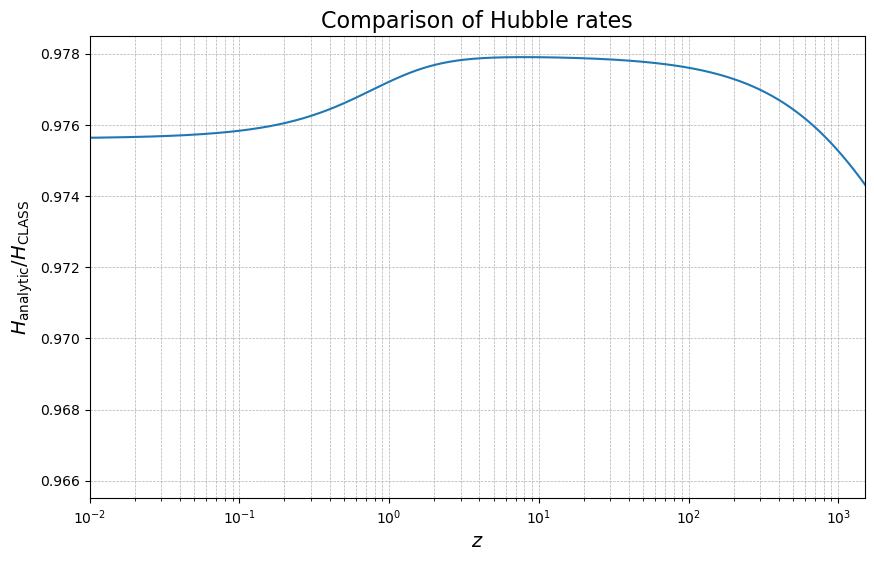

In [6]:
plt.figure(figsize=(10, 6))
plt.title('Comparison of Hubble rates', fontsize=16)
plt.xlabel(r'$z$', fontsize=14)
plt.ylabel(r'$H_{\mathrm{analytic}}/H_{\mathrm{CLASS}}$', fontsize=14)
plt.xscale('log')
plt.xlim(1e-2, 1500)
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.plot(z_num, Hratio)
plt.show()

To enforce exact agreement between the numerical and CLASS backgrounds, we construct an interpolating function $R(a)$ from the previous step and define a corrected Hubble function:

$$H_{\rm corr}(a) =
\frac{H_{\rm numerical}(a)}{R(a)}\, .$$

By construction:

$$H_{\rm corr}(a) \approx H_{\rm CLASS}(a)\, .$$

We will use $H_{\rm corr}(a)$ for all subsequent evolution.

Using $H_{\rm corr}(a)$, we recompute the conformal time:

$$\tau(a) = \int \frac{da}{a^2 H_{\rm corr}(a)}\, ,
$$
and solve:
$$
\frac{da}{d\tau} = a^2 H_{\rm corr}(a)\, ,
$$
to obtain the corrected mapping $a(\tau)$.

This ensures that both Hubble rate and scale-factor evolution match the CLASS background.

We then compare $\tau_{\rm corr}(a)$ with $\tau_{\rm CLASS}(a)$.


/var/folders/zk/048kkx6x4ws9g9qbphfnvj600000gn/T/ipykernel_14950/3199468003.py:16: RuntimeWarning: divide by zero encountered in divide
  tau_ratio=tau_class_of_a(a_num_corr)/tau_grid_corr


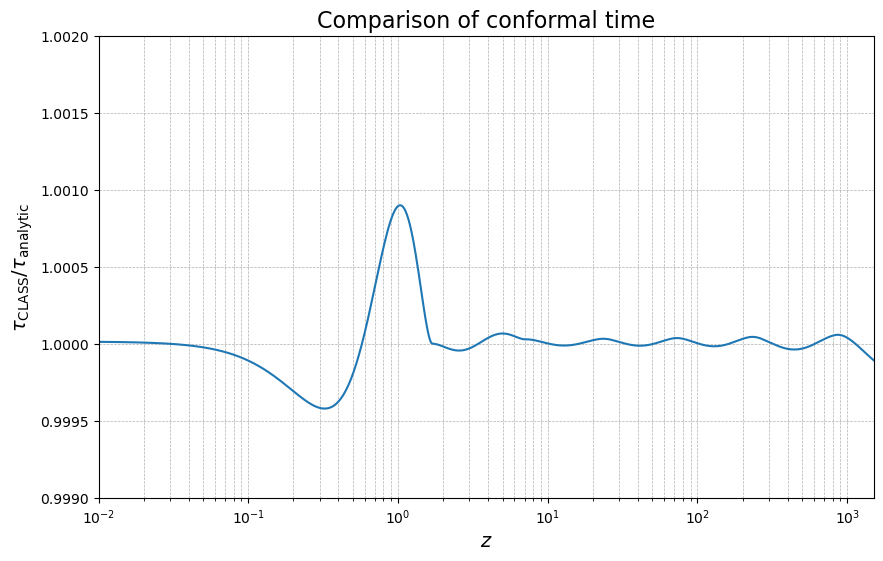

In [7]:
Hratio_func=sp.interpolate.interp1d(a_num, Hratio, kind='cubic', fill_value='extrapolate')

def H_corr(a):
    return H0/Hratio_func(a)*np.sqrt(Omegar*a**(-4)+Omegam*a**(-3)+Omegak*a**(-2)+OmegaL)
def dadt_corr(t, a):
    return a**2*H_corr(a)


tau_fin_corr=sp.integrate.quad(lambda a:1./(a**2*H_corr(a)), 1e-8, 1)[0]
a_tau_corr=sp.integrate.solve_ivp(dadt_corr, (0, tau_fin_corr), [a_ini], dense_output=True)
tau_grid_corr=np.linspace(0, tau_fin_corr, 40000)
a_num_corr=a_tau_corr.sol(tau_grid_corr)[0]
z_num_corr=1./a_num_corr-1.

tau_class_of_a=sp.interpolate.interp1d(a_class, tau_class, kind='cubic', fill_value='extrapolate')
tau_ratio=tau_class_of_a(a_num_corr)/tau_grid_corr

plt.figure(figsize=(10, 6))
plt.title('Comparison of conformal time', fontsize=16)
plt.xscale('log')
plt.xlabel(r'$z$', fontsize=14)
plt.ylabel(r'$\tau_{\mathrm{CLASS}}/\tau_{\mathrm{analytic}}$', fontsize=14)
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.xlim(1e-2, 1500)
plt.ylim(0.999, 1.002)
plt.plot(z_num_corr, tau_ratio)
plt.show()

We now evolve the scalar field $\chi(\tau)$ on the corrected background.
The equation of motion is:
$$
\chi'' + 2 a H_{\rm corr}(a)\, \chi' + a^2 V'(\chi) = 0\, ,
$$
with potential
$$
V(\chi)
= M_{\rm pl}^2\, m_\chi^2\,
\left[ 1 - \cos\!\left(\frac{\chi}{M_{\rm pl}}\right) \right]^2\, .
$$
The field begins frozen at early times:
$$
\chi(\tau_{\rm ini}) = M_{\rm pl}/\sqrt{8\pi},
\qquad
\chi'(\tau_{\rm ini}) = 0\, .
$$
We solve the equation for several values of $m_\chi$, and plot:
$$
\frac{\chi(\tau)}{\chi_{\rm ini}}
\quad\text{vs}\quad z\, .
$$


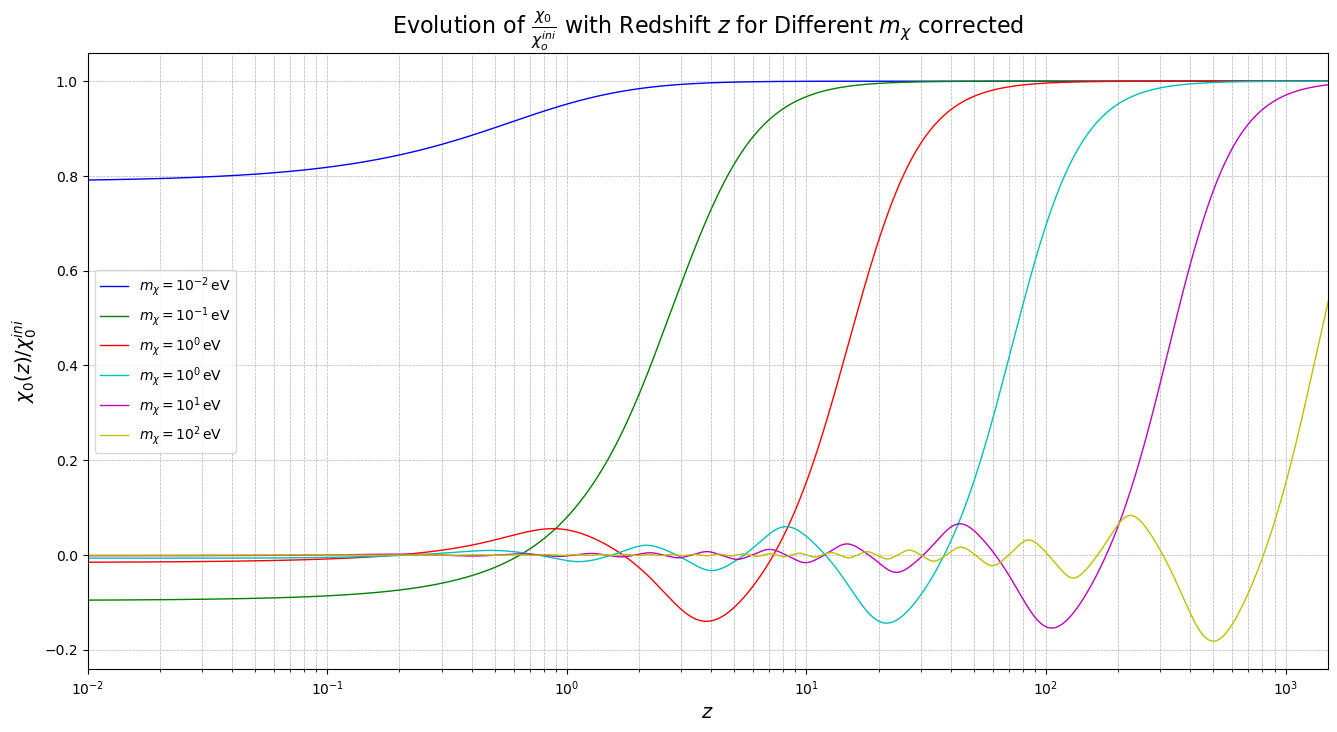

In [8]:
def V(x0, mx):
    return Mpl**2*mx**2*(1-np.cos(x0/Mpl))**2

def Vp(x0, mx):
    return 2*Mpl*mx**2*np.sin(x0/Mpl)*(1-np.cos(x0/Mpl))

def eom(tau, y, mx):
    x0, vx=y
    a=np.interp(tau, tau_grid_corr, a_num_corr)
    return [vx, -2*a*H_corr(a)*vx-a**2*Vp(x0, mx)]


mx_values=np.logspace(-32, -27, 6)*1.5637e29
def LaTex_mass(mx):
    exp=int(np.log10(mx))
    return rf'10^{{{exp}}}'


plt.figure(figsize=(16, 8))
colors=['b', 'g', 'r', 'c', 'm', 'y']

for mx, col in zip(mx_values, colors):
    initial_conditions=[mpl, 0]
    solution=sp.integrate.solve_ivp(eom, (0,tau_fin_corr), initial_conditions, args=(mx,), dense_output=True)
    
    chi_tau=solution.sol(tau_grid_corr)[0]
    s=chi_tau/initial_conditions[0]
   
    plt.plot(z_num_corr, s, color=col, label=rf'$m_\chi = {LaTex_mass(mx)}\, \mathrm{{eV}}$', linewidth=1)


plt.xscale('log')
plt.xticks([1e-2, 1e-1, 1e0, 1e1, 1e2, 1e3])
plt.xlabel(r'$z$', fontsize=14)
plt.xlim(1e-2, 1500)
plt.ylabel(r'$\chi_0 (z)/ \chi_0^{ini}$', fontsize=14)
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.title(r'Evolution of $\frac{\chi_0}{\chi_o^{ini}}$ with Redshift $z$ for Different $m_\chi$ corrected', fontsize=16)
plt.legend()
plt.show()

Finally, we compute the scalar-field equation of state:
$$
\omega_\chi(z) =
\frac{p_\chi}{\rho_\chi}
=
\frac{\chi'^2 - 2 a^2 V(\chi)}
{\chi'^2 + 2 a^2 V(\chi)}\, .
$$

This expression is evaluated entirely on the corrected background:\
	•	scale factor $a(\tau)$,\
	•	Hubble function $H_{\rm corr}(a)$,\
	•	field values $\chi(\tau)$,\
	•	field derivatives $\chi'(\tau)$.

We plot $\omega_\chi(z)$ for several masses.

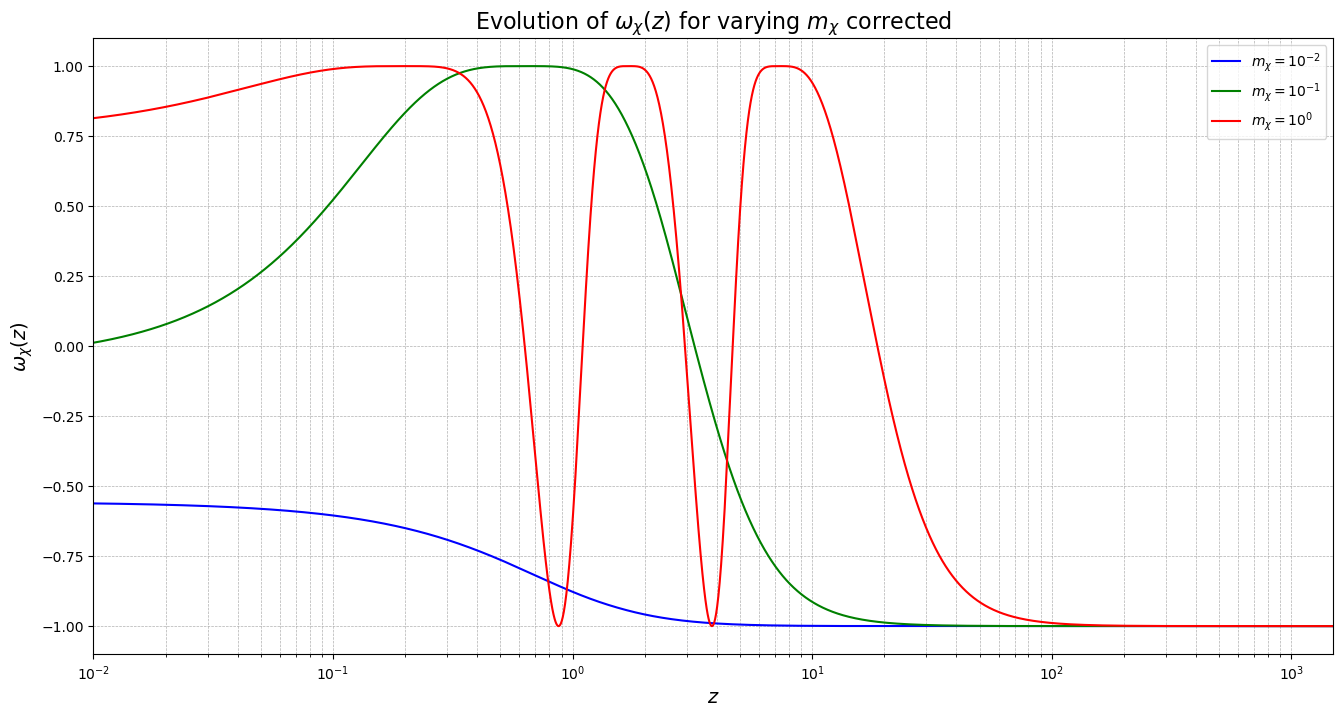

In [9]:
plt.figure(figsize=(16, 8))
plt.xscale('log')

mx_values=np.logspace(-32, -30, 3)*1.5637e29
for mx, col in zip(mx_values, colors):
    initial_conditions=[mpl, 0]
    solution=sp.integrate.solve_ivp(eom, (0, tau_fin_corr), initial_conditions, args=(mx,), dense_output=True)

    vx_solution=solution.sol(tau_grid_corr)[1]
    
    omega=(vx_solution**2-2*a_tau_corr.sol(tau_grid_corr)[0]**2*V(solution.sol(tau_grid_corr)[0], mx))/(vx_solution**2+2*a_tau_corr.sol(tau_grid_corr)[0]**2*V(solution.sol(tau_grid_corr)[0], mx))
   
    plt.plot(z_num_corr, omega, color=col, label=rf'$m_\chi={LaTex_mass(mx)}$') 


plt.xlabel(r'$z$', fontsize=14)
plt.xlim(1e-2, 1500)
plt.ylabel(r'$\omega_\chi(z)$', fontsize=14)
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.title(r'Evolution of $\omega_\chi(z)$ for varying $m_\chi$ corrected', fontsize=16)
plt.legend()
plt.show() 